In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle

import subcluster_funcs as funcs
sc._settings.settings._vector_friendly=True

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)

In [3]:
cell_type = "Neuronal"

In [4]:
adata = sc.read_h5ad("../post_subclustering/" + cell_type  + ".h5ad")

<Axes: xlabel='leiden', ylabel='sil_score'>

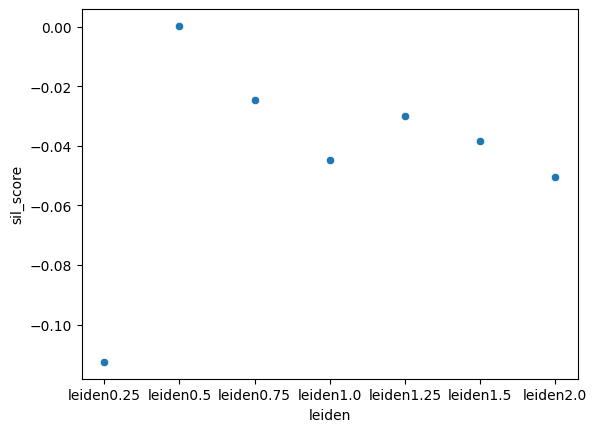

In [5]:
funcs.silhouette(adata, cell_type = cell_type)

### Use Leiden 0.25

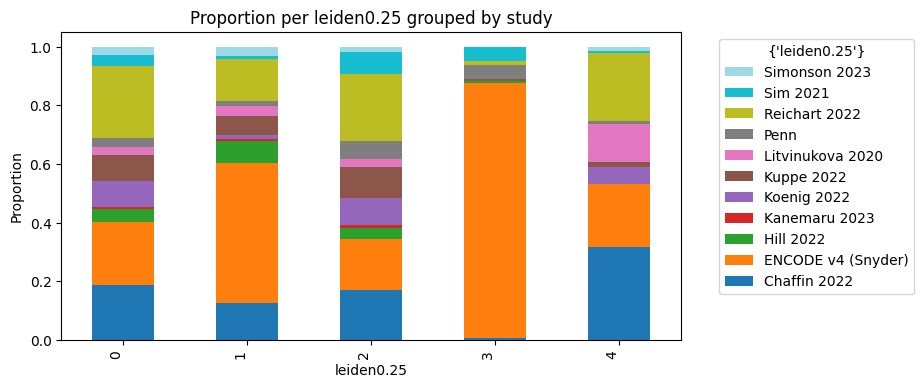

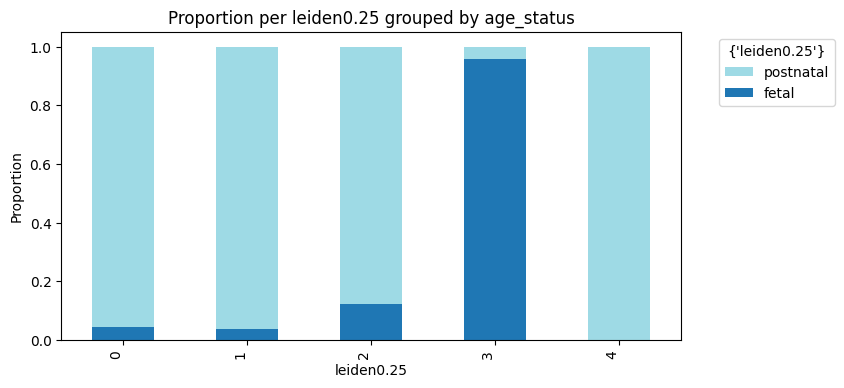

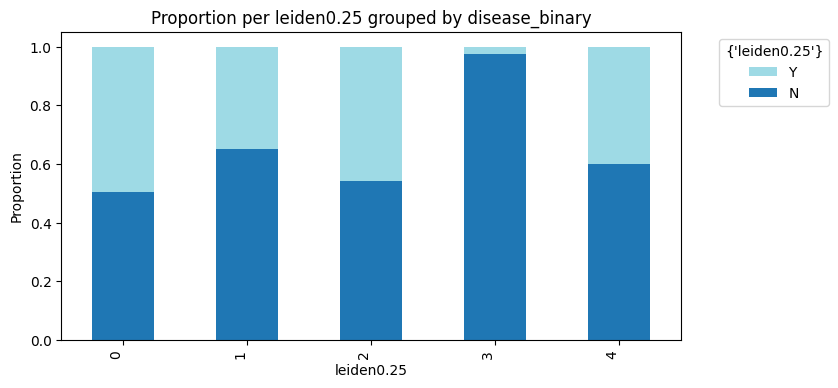

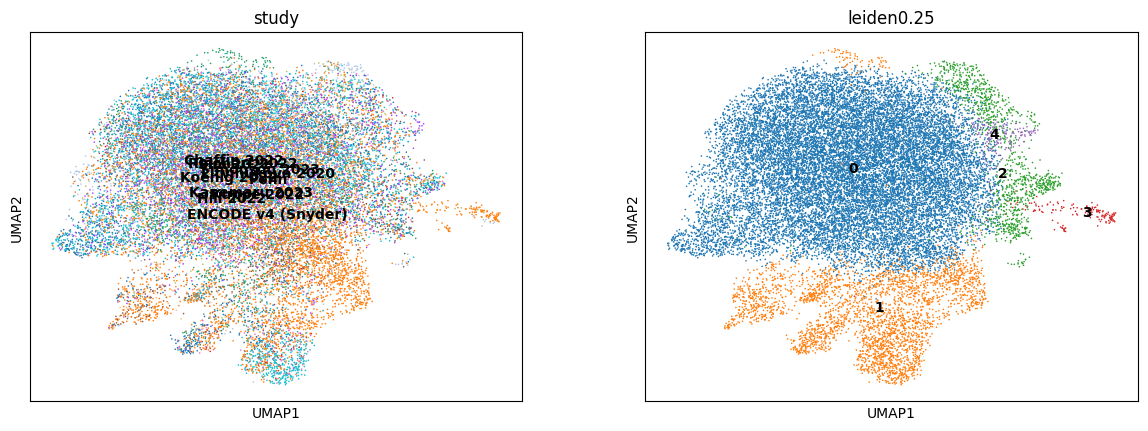

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (sel

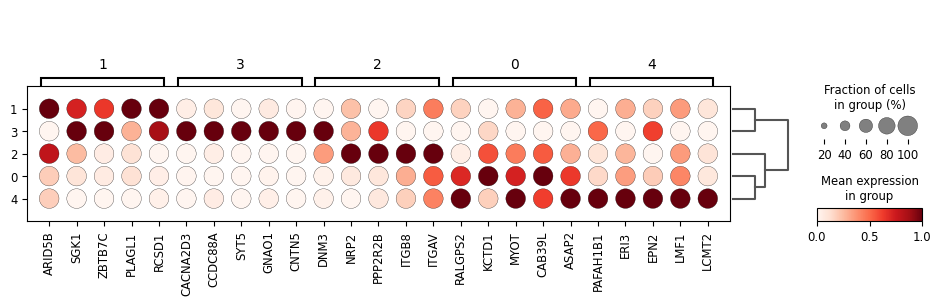

Counter({'0': 17906, '1': 3182, '2': 1172, '4': 190, '3': 163})


['leiden0.25',
 AnnData object with n_obs × n_vars = 22613 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0'
     var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0', 'neighbors', 'pca', 'rank_genes_groupsleiden0.1', 'rank_genes_groupsleiden0.25', 'rank_genes_groupsleiden0.5', 'rank_genes_groupsleiden0.75', 'rank_genes_groupsleiden1.0', '

In [6]:
funcs.specify_leiden_subclustering(adata=adata, leiden="leiden0.25")

- Cluster 0 are the main cluster, expressing NRXN1/3 (call this "other")
- Cluster 1 are autonomic 
- Cluster 2 are autonomic neurons (PRDM16, GAP43, TANC1/2, NAV3)
- Cluster 3 are from one study (mostly fetal)
- Cluster 4 is also a very small cluster

{'mainplot_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

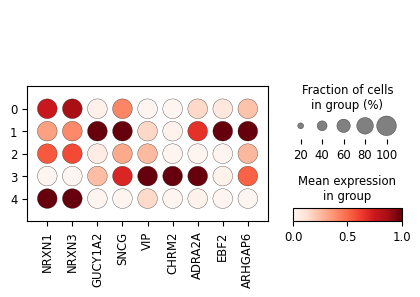

In [7]:
sc.pl.dotplot(adata, var_names = ["NRXN1", "NRXN3", "GUCY1A2", "SNCG", "VIP",
                                  "CHRM2", "ADRA2A", "EBF2", "ARHGAP6"],
              groupby = "leiden0.25", show=False, standard_scale='var', layer="scvi_normalized")

In [16]:
sc.get.rank_genes_groups_df(adata, group="1").head(50)['names']

0        ARID5B
1          SGK1
2        ZBTB7C
3        PLAGL1
4         RCSD1
5      SIGLECL1
6          EBF2
7          TNXB
8          PID1
9        TMEM61
10        DAAM1
11        KLK12
12       SLC9A9
13        NPAS2
14        ITGB5
15      ZNF385D
16        DACH1
17        ACER2
18       ZBTB46
19       DIAPH2
20         EGFR
21          OTP
22      GUCY1A2
23       TWIST2
24         TLE4
25         DAB2
26      CYSLTR2
27       MICAL2
28     ARHGAP22
29        CALD1
30      LRRFIP1
31        SMOC2
32        GRID1
33      CACNA1C
34     SERPINE1
35     ARHGAP10
36       STEAP4
37        MECOM
38         BNC2
39         FMO2
40    LINC01087
41        RGPD2
42        KALRN
43      FAM110B
44      ARHGAP6
45     ARHGAP44
46        ABCC9
47       PPP1CB
48         SOBP
49       CMKLR1
Name: names, dtype: object

In [9]:
adata.obs['subcluster'] = adata.obs['leiden0.25'].map(
    {"0": "Other",
     "1": "Sympathetic",
     "2": "Other",
     "3": "Other",
     "4": "Other",
    }
)

In [10]:
subcluster_order = ["Sympathetic", "Other"]

adata.obs['subcluster'] = pd.Categorical(
    adata.obs['subcluster'], categories=subcluster_order, ordered=True
)

subcluster_colors = {
    "Sympathetic": "#1f77b4",     # blue
    "Other": "#D3D3D3",    # light gray
}

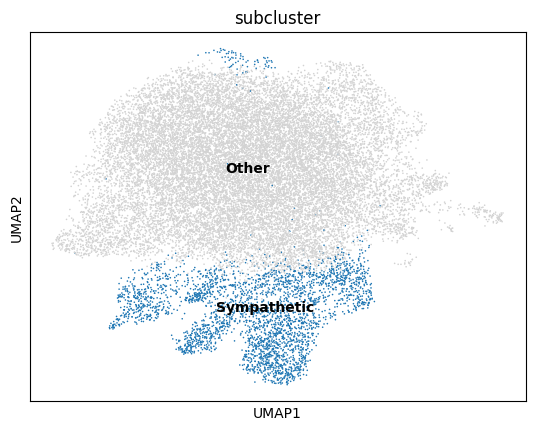

In [11]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette = subcluster_colors, show=False)
    plt.savefig("Neuronal_subclustered.pdf", bbox_inches="tight")

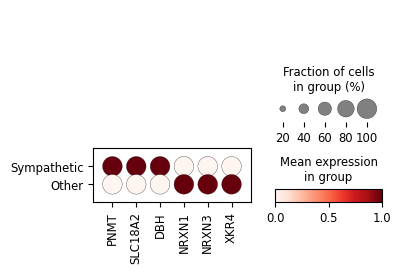

In [12]:
with plt.rc_context(): 
    sc.pl.dotplot(adata, var_names = ["PNMT", "SLC18A2", "DBH",
                                      "NRXN1", "NRXN3", "XKR4"], groupby = "subcluster", layer="scvi_normalized",
                  standard_scale='var', show=False)
    plt.savefig("Neuronal_subclustered_dotplot.pdf", bbox_inches="tight")

In [13]:
subcluster_stats = (
    adata.obs['subcluster']
    .value_counts(normalize=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "subcluster"})
)

subcluster_stats["proportion"] = subcluster_stats["count"] / subcluster_stats["count"].sum()

print(subcluster_stats)

    subcluster  count  proportion
0        Other  19431    0.859284
1  Sympathetic   3182    0.140716
